In [36]:
from hashlib import sha256
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import unittest
import math
import random

In [37]:
class HyperLogLog:
    def __init__(self, eps:float = 0, p:int = 0):
        if eps != 0: 
            self.p = math.ceil(2 * math.log((1.04/eps), 2))
        else:
            self.p = p
        self.m = 2 ** self.p
        self.registers = [0] * self.m
        if self.m == 16:
            self.alpha = 0.673
        elif self.m == 32:
            self.alpha = 0.697
        elif self.m == 64:
            self.alpha = 0.709
        else:
            self.alpha = 0.7213 / (1 + 1.079 / self.m)
    

    def add(self, item):
        h_bytes = sha256(str(item).encode('utf-8')).digest()
        x = int.from_bytes(h_bytes[:8], 'big')
        
        idx = x >> (64 - self.p)
        
        w = x & ((1 << (64 - self.p)) - 1)

        if w > 0:
            rho = (64 - self.p - w.bit_length() + 1)
        else:
            rho = (64 - self.p + 1)
        
        self.registers[idx] = max(self.registers[idx], rho)

    def count(self):

        sum_registers = sum(2.0 ** -r for r in self.registers)
 
        estimate = self.alpha * (self.m ** 2) / sum_registers

        if estimate <= 2.5 * self.m:
            zeros = self.registers.count(0)
            if zeros > 0:
                estimate = self.m * math.log(self.m / zeros)

        elif estimate > (1/30) * (2**64):
            estimate = -(2**64) * math.log(1 - estimate / (2**64))

        return int(estimate)
    
    def __add__(self, other):
        if self.p != other.p:
            raise ValueError("Нельзя объединять HyperLogLog с разными параметрами p")
            
        merged = HyperLogLog(p=self.p)
        
        merged.registers = [max(r1, r2) for r1, r2 in zip(self.registers, other.registers)]
        
        return merged

In [38]:
def date_generator():
    # Точка отсчета
    start_date = datetime(2000, 1, 1)
    
    while True:
        # Генерируем случайное смещение в секундах (на ~100 лет вперед)
        random_seconds = random.randint(0, 31536000 * 100)
        current_date = start_date + timedelta(seconds=random_seconds)
        
        # yield возвращает значение и "замораживает" функцию до следующего вызова
        yield current_date.isoformat()

In [39]:
class TestHyperLogLog(unittest.TestCase):
    def test_accuracy_on_streams(self):
        # Наши размеры потоков из задания
        test_sizes = [
                        10_000,
                        250_000,
                        1_150_000
                    ]
        
        print("\n" + "="*50)
        print(f"{'Поток':<10} | {'Реально':<10} | {'Оценка':<10} | {'Ошибка %'}")
        print("-" * 50)

        for n in test_sizes:
            # Создаем HLL с p=14 (хорошая точность ~0.8%)
            hll = HyperLogLog(p=14)
            gen = date_generator()
            
            # Нам нужно знать реальное кол-во уникальных для проверки
            # (в реальной жизни HLL как раз и нужен, чтобы НЕ хранить этот set)
            unique_elements = set()
            
            for _ in range(n):
                item = next(gen)
                hll.add(item)
                unique_elements.add(item)
            
            real_count = len(unique_elements)
            estimated = hll.count()
            
            # Считаем относительную ошибку
            error_percent = (abs(real_count - estimated) / real_count) * 100
            
            print(f"{n:<10} | {real_count:<10} | {estimated:<10} | {error_percent:.2f}%")
            
            # Проверяем, что ошибка не вылетает за разумные 5%
            self.assertLess(error_percent, 5.0)
        
        def test_merge_structures(self):
            hll1 = HyperLogLog(p=14)
            hll2 = HyperLogLog(p=14)
            
            # Добавляем по 5000 разных элементов в каждый
            for i in range(5000): hll1.add(f"stream1_{i}")
            for i in range(5000): hll2.add(f"stream2_{i}")
            
            # Складываем через перегруженный оператор + (Пункт 2)
            hll_total = hll1 + hll2
            
            result = hll_total.count()
            print(f"\nОбъединение: Ожидаем ~10000, Получили {result}")
            self.assertAlmostEqual(result, 10000, delta=500)

In [40]:
def plot_error_dependency():
    n = 100_000  # Фиксированный размер потока
    p_values = list(range(4, 19))  # p от 4 до 18
    actual_errors = []
    theoretical_errors = []

    # Генерируем тестовый набор данных один раз
    print("Генерация данных для теста...")
    test_data = [f"item_{i}" for i in range(n)]

    for p in p_values:
        hll = HyperLogLog(p=p)
        for item in test_data:
            hll.add(item)
        
        est = hll.count()
        # Считаем реальную относительную ошибку в процентах
        rel_error = (abs(n - est) / n) * 100
        actual_errors.append(rel_error)
        
        # Считаем теоретическую ошибку по формуле: 1.04 / sqrt(m)
        m = 1 << p
        theo_error = (1.04 / math.sqrt(m)) * 100
        theoretical_errors.append(theo_error)
        
        print(f"p={p:2} | m={m:6} | Ошибка: {rel_error:.2f}% (Теор: {theo_error:.2f}%)")

    # Строим график
    plt.figure(figsize=(10, 6))
    plt.plot(p_values, actual_errors, 'ro-', label='Реальная погрешность')
    plt.plot(p_values, theoretical_errors, 'b--', label='Теоретическая (1.04/sqrt(m))')
    
    plt.yscale('log') # Логарифмическая шкала лучше показывает падение ошибки
    plt.xticks(p_values)
    plt.xlabel('Параметр p (кол-во бит)')
    plt.ylabel('Относительная ошибка (%)')
    plt.title('Зависимость погрешности HyperLogLog от параметра p')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()


Генерация данных для теста...
p= 4 | m=    16 | Ошибка: 27.97% (Теор: 26.00%)
p= 5 | m=    32 | Ошибка: 17.03% (Теор: 18.38%)
p= 6 | m=    64 | Ошибка: 7.34% (Теор: 13.00%)
p= 7 | m=   128 | Ошибка: 8.31% (Теор: 9.19%)
p= 8 | m=   256 | Ошибка: 0.48% (Теор: 6.50%)
p= 9 | m=   512 | Ошибка: 0.54% (Теор: 4.60%)
p=10 | m=  1024 | Ошибка: 1.88% (Теор: 3.25%)
p=11 | m=  2048 | Ошибка: 0.94% (Теор: 2.30%)
p=12 | m=  4096 | Ошибка: 0.80% (Теор: 1.62%)
p=13 | m=  8192 | Ошибка: 2.56% (Теор: 1.15%)
p=14 | m= 16384 | Ошибка: 0.21% (Теор: 0.81%)
p=15 | m= 32768 | Ошибка: 0.76% (Теор: 0.57%)
p=16 | m= 65536 | Ошибка: 0.65% (Теор: 0.41%)
p=17 | m=131072 | Ошибка: 0.16% (Теор: 0.29%)
p=18 | m=262144 | Ошибка: 0.05% (Теор: 0.20%)


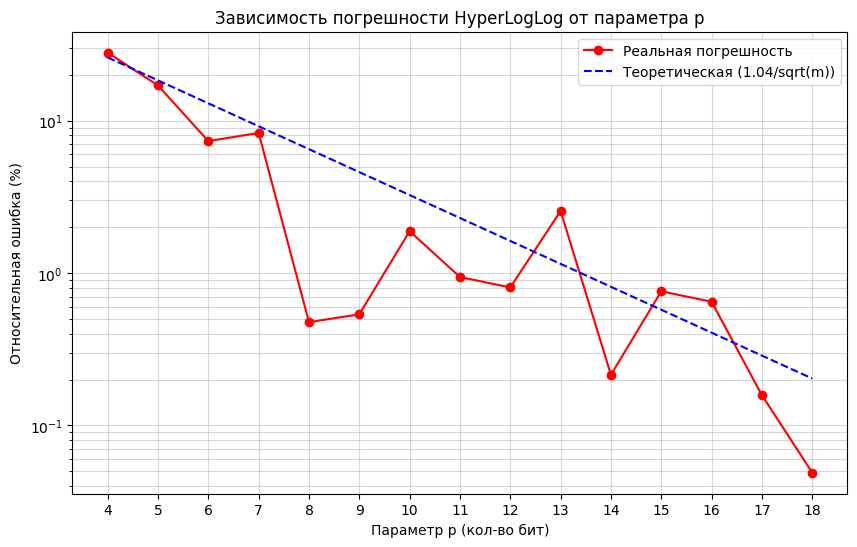

In [41]:
plot_error_dependency()